In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
plt.rcParams.update({'font.size': 10})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 
# from sps_common.constants import DM_CONSTANT, FREQ_BOTTOM, FREQ_TOP, TSAMP
# from ps_processes.processes.ps_inject import gaussian
from astropy.coordinates import SkyCoord 
from astropy import units as u

In [2]:
DM_CONSTANT = 1.0 / 2.41e-4
# The frequency of the top part of the CHIME band
FREQ_TOP = 800.1953125
# The frequency of the bottom part of the CHIME band
FREQ_BOTTOM = 400.1953125
TSAMP = 0.00098304

def gaussian(mu, sig):
    x = np.linspace(0, 1, 1024)
    return np.exp(-0.5 * ((x - mu) / sig) ** 2) / (sig * np.sqrt(2 * np.pi))

In [3]:
data_1 = np.concatenate((np.loadtxt('single_day_20260402_results.txt'),
                         np.loadtxt('single_day_2026_04_05_injections.txt'),
                         np.loadtxt('single_day_2026_04_08_injections.txt'),
                         np.loadtxt('single_day_2026_04_11_injections.txt'),
                         np.loadtxt('single_day_2026_04_14_injections.txt')))
data_1[:, 2] = 1
data_5 = np.loadtxt('5_day_injections.txt')
data_6 = np.loadtxt('6_day_injections.txt')
data_7 = np.loadtxt('7_day_injections.txt')
data_8 = np.loadtxt('8_day_injections.txt')
data_9 = np.loadtxt('9_day_injections.txt')
data_10 = np.loadtxt('10_day_injections.txt')
data_11 = np.loadtxt('11_day_injections.txt')
data_12 = np.loadtxt('12_day_injections.txt')
data_13 = np.loadtxt('13_day_injections.txt')
data_14 = np.loadtxt('14_day_injections.txt')
data_15 = np.loadtxt('15_day_injections.txt')
data_16 = np.loadtxt('16_day_injections.txt')
data_17 = np.loadtxt('17_day_injections.txt')
data_18 = np.loadtxt('18_day_injections.txt')
data_19 = np.loadtxt('19_day_injections.txt')
data_20 = np.loadtxt('20_day_injections.txt')

f_idx = 4
DM_idx = 5
S_idx = 6
FWHM_idx = 7

In [27]:
p_total = []

data_unglob = [
    data_1,
#    data_9,
    data_10,
    data_11,
    data_12,
    data_13,
    data_14,
    data_15,
    data_16,
    data_17,
    data_18,
#    data_19,
#    data_20
]

data = []
days = []

for datum in data_unglob:

    fglob_mask = (datum[:, f_idx] > 0.1) & (datum[:, f_idx] < 250.)
    DMglob_mask = (datum[:, DM_idx] > 1.) & (datum[:, DM_idx] < 600.)
    Sglob_mask = datum[:, S_idx] > 0.1
    FWHMglob_mask = (datum[:, FWHM_idx] > 0.014) & (datum[:, FWHM_idx] < 0.034)
    glob_mask = fglob_mask & DMglob_mask & Sglob_mask & FWHMglob_mask
    datum = datum[glob_mask]

    p = len(datum[datum[:, -1] > 0.]) / len(datum)
    print(f'{int(datum[0, 2])}-day stack: {len(datum)} injections, p({int(datum[0, 2])}) = {p:.2f}')
    p_total.append(p)
    days.append(datum[0, 2])

    data.append(datum)

days = np.array(days)

1-day stack: 7218 injections, p(1) = 0.58
10-day stack: 3381 injections, p(10) = 0.72
11-day stack: 9645 injections, p(11) = 0.79
12-day stack: 20119 injections, p(12) = 0.80
13-day stack: 27894 injections, p(13) = 0.82
14-day stack: 17234 injections, p(14) = 0.82
15-day stack: 4001 injections, p(15) = 0.82
16-day stack: 9140 injections, p(16) = 0.82
17-day stack: 10481 injections, p(17) = 0.81
18-day stack: 13543 injections, p(18) = 0.83


Text(0, 0.5, 'p(N)')

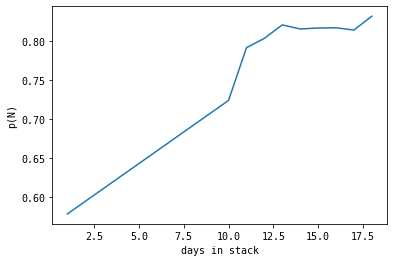

In [28]:
plt.plot(days, p_total)
plt.xlabel('days in stack')
plt.ylabel('p(N)')

In [29]:
S_idx = 6
S_bins = np.logspace(-2, 1, 200)
S_dev = 10

S_hot = np.zeros(len(data))
S_cold = np.zeros(len(data))

for i in range(len(data)):

    coords = SkyCoord(ra=data[i][:, 0]*u.deg, dec=data[i][:, 1]*u.deg, frame='icrs')
    galactic_lat = coords.galactic.b
    low_b_mask = np.abs(galactic_lat) < 5*u.degree
    high_b_mask = np.abs(galactic_lat) > 10*u.degree 

    _, S_sens, S_smooth = au.get_sensitivity(
        data[i][low_b_mask],
        *(S_idx, S_bins, S_dev)
    )

    S_hot[i] = np.max(S_bins[np.where(S_smooth < 0.50)[0]])

    _, S_sens, S_smooth = au.get_sensitivity(
        data[i][high_b_mask],
        *(S_idx, S_bins, S_dev)
    )

    S_cold[i] = np.max(S_bins[np.where(S_smooth < 0.50)[0]])



/home/rns/work/Transmissivity/scripts/analysis_utils.py:32: RuntimeWarning: invalid value encountered in divide
  arr_ret_p_smooth = arr_ret_smooth / arr_inj_smooth
/home/rns/work/Transmissivity/scripts/analysis_utils.py:34: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected


Lorimer & Kramer:
$$S_{min} = \frac{\beta (T_{sys} + T_{sky})}{G} \frac{1}{\sqrt{N_{pol}\tau \Delta \nu}} \sqrt{\frac{\delta}{1 - \delta}} \text{SNR} $$

where $\delta$ is the effective width.

Assuming that we will find >50% of everything with SNR > 10, and choosing $b = 0^{\circ}$ and $l = 90^{\circ}$:

In [30]:
GAIN = 1.16e-3  # K mJy^-1
TSYS = 50  # K
BETA = 1.1
NPOL = 2
TAU = 20* 10 * 60 #s
F_NYQUIST = 508 #Hz
BANDWIDTH = 400e6 #Hz

#envelope functions:
def get_nchans(maxdm):
    """
    Inputs a pointing dict with ra, dec, maxdm and returns nchans.

    Inputs
    pointing - A dict of ra, dec, maxdm
    """
    if maxdm <= 212.5:
        nchans = 1024
    elif maxdm <= 425:
        nchans = 2048
    elif maxdm <= 850:
        nchans = 4096
    elif maxdm <= 1700:
        nchans = 8192
    else:
        nchans = 16384
    return nchans


def get_dedispersion_time():

    #max DM offset we can have for channelization of 0.1 pcc
    delta_DM = 0.05 #pc / cm^-3 
    
    dt = DM_CONSTANT * delta_DM * (1/FREQ_BOTTOM**2 - 1/FREQ_TOP**2)
    
    return dt

def time_windowing(prof_fft, f):
    # apply Van der Klis Eq 2.19 for time-bin windowing effect
    harmonic_freqs = np.arange(1, len(prof_fft) + 1) * f
    B = np.sinc(harmonic_freqs * TSAMP)
    prof_fft *= B

    return prof_fft

def get_intrachannel_time(DM, maxDM):
        
    nchan = get_nchans(maxDM)

    quadratic_terms = {
            "1024": 1e-8,
            "2048": 6e-9,
            "4096": 3e-9,
            "8192": 1.5e-9,
            "16384": 8e-10,
        }
    quadratic_term = quadratic_terms[str(nchan)]

    t_intrachannel = DM * DM_CONSTANT * quadratic_term
    
    return t_intrachannel

def radiometer(f, DM, SNR, FWHM, maxDM, Tsky, Ndays):

    FWHM /= f #in s
    tau = Ndays * 10 * 60 #days x minutes / day x seconds / minute
 
    t_dedisp = get_dedispersion_time() #in s
    t_intrach = get_intrachannel_time(DM, maxDM)
    
    FWHM = np.sqrt(FWHM**2 + t_dedisp**2 )
    FWHM = np.sqrt(FWHM**2 + t_intrach**2)
    FWHM = np.sqrt(FWHM**2 + TSAMP**2)

    system_terms =  BETA * (TSYS + Tsky) / GAIN
    obs_terms = 1 / np.sqrt(NPOL * tau * (BANDWIDTH / 2)) #for rfi...
    pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM)) 

    return system_terms * obs_terms * pulse_terms * SNR

def get_Scurve(f, DM, SNR, FWHM, maxDM, Tsky, Ndays):

    Smin = np.zeros((len(DM), len(f)))

    for k in range(len(DM)):
        for l in range(len(f)):
            S_temp = radiometer(f[l], DM[k], SNR, FWHM, maxDM, Tsky, Ndays)
            Smin[k, l] = S_temp

    return Smin


(0.031157627800878614, 13.121371734219267)

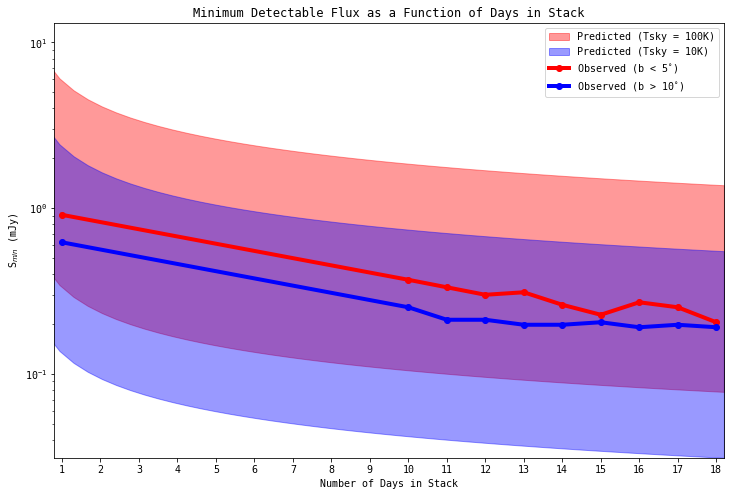

In [38]:
many_days = np.linspace(0.2, 18.2)
Smin_hot_mid = radiometer(f = 1, DM = 0, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 100., Ndays = many_days) 
Smin_hot_fast = radiometer(f = 100, DM = 212.5, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 100., Ndays = many_days) 
Smin_cold_mid = radiometer(f = 1, DM = 0, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 10., Ndays = many_days) 
Smin_cold_fast = radiometer(f = 100, DM = 212.5, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 10., Ndays = many_days) 

fig, ax = plt.subplots(1, 1, figsize = (12, 8))
ymax = max(Smin_hot_fast)

mask_hot = np.isfinite(Smin_hot_fast)
mask_cold = np.isfinite(Smin_cold_fast)

upper_hot = np.where(mask_hot, Smin_hot_fast, ymax)
upper_cold = np.where(mask_cold, Smin_cold_fast, ymax)

ax.fill_between(many_days, Smin_hot_mid, Smin_hot_fast,
                color='r', alpha=0.4, label='Predicted (Tsky = 100K)')
ax.fill_between(many_days, Smin_cold_mid, Smin_cold_fast,
                color='b', alpha=0.4, label='Predicted (Tsky = 10K)')

ax.plot(days, S_hot, 'r', marker = 'o', linewidth = '4.0', label = r'Observed (b < 5$^{\circ}$)')
ax.plot(days, S_cold, 'b', marker = 'o', linewidth = '4.0', label = r'Observed (b > 10$^{\circ}$)')

# ax.set_xlim(np.nanmin(many_days), np.nanmax(many_days))
# ax.set_ylim(np.nanmin(Smin_cold_mid), np.nanmax(Smin_hot_fast))

ax.legend()
ax.set_xticks(range(1, 19))
ax.set_xlabel('Number of Days in Stack')
ax.set_ylabel(r'S$_{min}$ (mJy)')
ax.set_yscale('log')
ax.set_title('Minimum Detectable Flux as a Function of Days in Stack')
ax.set_xlim(0.8, 18.2)
ax.set_ylim(np.nanmin(Smin_cold_mid), np.nanmax(Smin_hot_fast))

Below is a really complicated way of sorting all our data into chunks based off the channelization.

In [ ]:
all_data = np.concatenate(data_unglob, axis = 0)
coords = SkyCoord(ra=all_data[:, 0]*u.deg, dec=all_data[:, 1]*u.deg, frame='icrs')
galactic_lat = coords.galactic.b
low_b_mask = np.abs(galactic_lat) < 5*u.degree
high_b_mask = np.abs(galactic_lat) > 10*u.degree 

f_bins = np.logspace(np.log10(0.05), np.log10(250), 500)
f_dev = 50
S_bins = np.logspace(-2, 1, 500)
S_dev = 50

Smin_of_f = np.zeros((4, len(f_bins) - 1))
FWHM_lazarus_mask = (all_data[:, FWHM_idx] > 0.014) & (all_data[:, FWHM_idx] < 0.034)
DM_mask = (all_data[:, DM_idx] > 1.) 
length_mask = all_data[:, 2] == 14

print(f'Analyzing {len(all_data[FWHM_lazarus_mask & DM_mask & length_mask & low_b_mask])} low-b injections.')
print(f'Analyzing {len(all_data[FWHM_lazarus_mask & DM_mask & length_mask & high_b_mask])} high-b injections.')

'''
_____________________
HOT SKY
'''
_, f_S_unsmooth_hot, f_S_smooth_hot = au.get_sensitivity(
    all_data[FWHM_lazarus_mask & DM_mask & low_b_mask],
    *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
    stype = '2d',
)

for j in range(len(f_bins) - 1):

    try:
        Smin_of_f[0, j] = np.min(S_bins[np.where(f_S_smooth_hot[j] > 0.50)[0]])
    except:
        Smin_of_f[0, j] = np.nan

'''
_____________________
COLD SKY
'''
_, f_S_unsmooth_cold, f_S_smooth_cold = au.get_sensitivity(
    all_data[FWHM_lazarus_mask & DM_mask & high_b_mask],
    *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
    stype = '2d',
)

for j in range(len(f_bins) - 1):

    try:
        Smin_of_f[1, j] = np.min(S_bins[np.where(f_S_smooth_cold[j] > 0.50)[0]])
    except:
        Smin_of_f[0, j] = np.nan

Smin_of_f[0] = gaussian_filter(Smin_of_f[0], 5)
Smin_of_f[1] = gaussian_filter(Smin_of_f[1], 5)


predicted_Smin_of_f = np.zeros((4, len(f_bins) - 1))
#shape is:
#hot sky, max DM 
#cold sky, max DM 
#hot sky, min DM 
#cold sky, min DM
predicted_Smin_of_f[0] = radiometer(f = f_bins[:-1], DM = 212.5, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 100, Ndays = 14)
predicted_Smin_of_f[1] = radiometer(f = f_bins[:-1], DM = 212.5, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 10, Ndays = 14)
predicted_Smin_of_f[2] = radiometer(f = f_bins[:-1], DM = 0, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 100, Ndays = 14)
predicted_Smin_of_f[3] = radiometer(f = f_bins[:-1], DM = 0, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 10, Ndays = 14)

Analyzing 1392 low-b injections.
Analyzing 30559 high-b injections.


/tmp/ipykernel_25872/215501640.py:78: RuntimeWarning: invalid value encountered in sqrt
  pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM))


Text(0.5, 1.0, 'Minimum Detectable Flux for 2 Week Stacks')

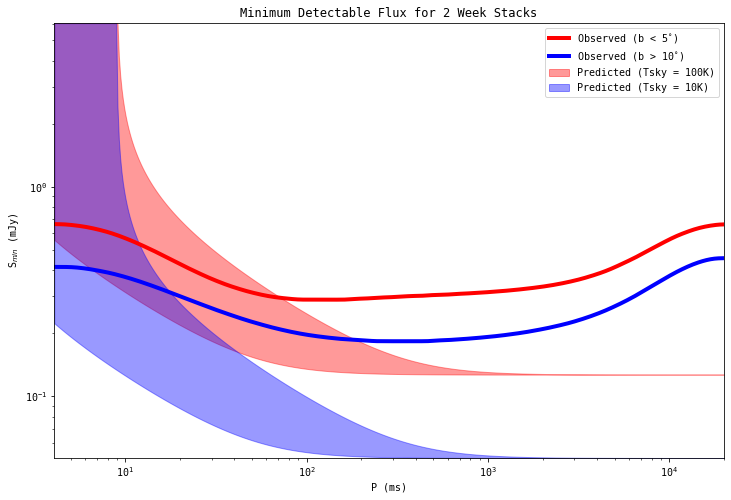

In [14]:
P = 1/f_bins[:-1]
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.plot(P*1e3, Smin_of_f[0], 'r', linewidth=4.0, label=r'Observed (b < 5$^{\circ}$)')
ax.plot(P*1e3, Smin_of_f[1], 'b', linewidth=4.0, label=r'Observed (b > 10$^{\circ}$)')

ax.loglog()
ymax = max(predicted_Smin_of_f[0])

mask_hot = np.isfinite(predicted_Smin_of_f[0])
mask_cold = np.isfinite(predicted_Smin_of_f[1])

upper_hot = np.where(mask_hot, predicted_Smin_of_f[0], ymax)
upper_cold = np.where(mask_cold, predicted_Smin_of_f[1], ymax)

ax.fill_between(P*1e3, predicted_Smin_of_f[2], upper_hot,
                color='r', alpha=0.4, label='Predicted (Tsky = 100K)')
ax.fill_between(P*1e3, predicted_Smin_of_f[3], upper_cold,
                color='b', alpha=0.4, label='Predicted (Tsky = 10K)')

ax.set_xlabel('P (ms)')
ax.set_ylabel(r'S$_{min}$ (mJy)')
ax.legend()
ax.set_xlim(min(P*1e3), max(P*1e3))
ax.set_ylim(min(predicted_Smin_of_f[3]), max(predicted_Smin_of_f[0]))
ax.set_title('Minimum Detectable Flux for 2 Week Stacks')